In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report, confusion_matrix
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [10]:
# ===============================================================
# OPTIMIZED AUTOENCODER FEATURE PIPELINE FOR PM2.5 PREDICTION
# ===============================================================
import os
import numpy as np
import pandas as pd
import kagglehub
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- CONFIG ---
MAX_FILES = 100      # limit for faster run
BATCH_SIZE = 1024    # efficient batching
EPOCHS = 10
ENCODING_DIM = 8
SAVE_PATH = "/kaggle/working/df_ae.csv"

# --- Load dataset from Kaggle Hub ---
data_path = kagglehub.dataset_download("abhisheksjha/time-series-air-quality-data-of-india-2010-2023")
file_path = os.path.join(data_path, "df_ae.csv")

# --- Try to load preprocessed dataset ---
if os.path.exists(SAVE_PATH):
    df_ae = pd.read_csv(SAVE_PATH)
    print(f"✅ Loaded preprocessed dataset from working directory: {SAVE_PATH}")

elif os.path.exists(file_path):
    df_ae = pd.read_csv(file_path)
    print(f"✅ Loaded preprocessed dataset from input directory: {file_path}")

else:
    print("⚠ df_ae.csv not found. Generating it from raw CSVs ...")

    # === STEP 1: Load all raw CSVs ===
    csv_files = [f for f in os.listdir(data_path) if f.endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("❌ No raw CSV files found in dataset directory!")

    dfs = []
    for file in tqdm(csv_files[:MAX_FILES], desc=f"Merging CSVs (up to {MAX_FILES})"):
        try:
            df = pd.read_csv(os.path.join(data_path, file))
            df["station_file"] = file
            dfs.append(df)
        except Exception as e:
            print(f"⚠ Error reading {file}: {e}")
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"✅ Merged {len(csv_files)} files — total rows: {len(df_all):,}")

    # === STEP 2: Clean columns ===
    df_all.columns = df_all.columns.str.strip()
    pm25_cols = [c for c in df_all.columns if "PM2.5" in c]
    if not pm25_cols:
        raise ValueError("❌ No PM2.5 column found in raw CSVs!")

    df_all = df_all.rename(columns={pm25_cols[0]: "PM2.5 (ug/m3)"})
    df_all = df_all.replace([np.inf, -np.inf], np.nan)
    df_all = df_all.dropna(subset=["PM2.5 (ug/m3)"])
    df_all = df_all.drop_duplicates()

    # === STEP 3: Numeric selection + cleanup ===
    num_df = df_all.select_dtypes(include=[np.number])
    num_df = num_df.fillna(num_df.median())

    # === STEP 4: Robust scaling ===
    scaler = RobustScaler()
    scaled_data = scaler.fit_transform(num_df)

    # === STEP 5: Build a stable autoencoder ===
    input_dim = scaled_data.shape[1]
    input_layer = Input(shape=(input_dim,))
    x = Dense(256, activation="relu")(input_layer)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    encoded = Dense(ENCODING_DIM, activation="relu", name="bottleneck")(x)

    x = Dense(64, activation="relu")(encoded)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    decoded = Dense(input_dim, activation="sigmoid")(x)

    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer=Adam(1e-3), loss="mse")

    es = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)

    autoencoder.fit(
        scaled_data, scaled_data,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1,
        callbacks=[es]
    )

    # === STEP 6: Extract features ===
    encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("bottleneck").output)
    ae_features = encoder.predict(scaled_data, batch_size=BATCH_SIZE, verbose=1)

    df_ae = num_df.copy()
    for i in range(ENCODING_DIM):
        df_ae[f"ae_feat_{i+1}"] = ae_features[:, i]

    # Reconstruction error
    recon = autoencoder.predict(scaled_data, batch_size=BATCH_SIZE, verbose=1)
    recon_mse = np.mean(np.square(scaled_data - recon), axis=1)
    df_ae["recon_mse"] = recon_mse

    # === STEP 7: Save safely ===
    df_ae.to_csv(SAVE_PATH, index=False)
    print(f"✅ Generated and saved df_ae.csv — shape: {df_ae.shape} at {SAVE_PATH}")

# --- Validation ---
if "PM2.5 (ug/m3)" not in df_ae.columns:
    raise ValueError("❌ Target column 'PM2.5 (ug/m3)' missing in df_ae")

ae_cols = [f"ae_feat_{i}" for i in range(1, ENCODING_DIM + 1)]
missing_ae = [col for col in ae_cols if col not in df_ae.columns]
if missing_ae:
    raise ValueError(f"❌ Missing autoencoder feature columns: {missing_ae}")

print("✅ df_ae is fully ready for PM2.5 prediction modeling pipeline.")


⚠ df_ae.csv not found. Generating it from raw CSVs ...


Merging CSVs (up to 100): 100%|██████████| 100/100 [00:04<00:00, 20.66it/s]


✅ Merged 454 files — total rows: 2,948,090
Epoch 1/10
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - loss: nan
Epoch 2/10
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: nan
Epoch 3/10
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: nan
Epoch 4/10
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - loss: nan
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
2136/2136 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
✅ Generated and saved df_ae.csv — shape: (2186571, 70) at /kaggle/working/df_ae.csv
✅ df_ae is fully ready for PM2.5 prediction modeling pipeline.


In [12]:
# ===========================
# Step 1: Dataset Preparation (Robust Fix)
# ===========================
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("STEP 1: Dataset Preparation (Fixed)")
print("=" * 60)

# Identify numeric feature columns (exclude AE & target)
ae_features = [col for col in df_ae.columns if col.startswith("ae_feat_")]
recon_col = "recon_mse" if "recon_mse" in df_ae.columns else None

exclude_cols = ["PM2.5 (ug/m3)"] + ae_features + ([recon_col] if recon_col else [])
original_numeric_columns = [
    col for col in df_ae.columns
    if col not in exclude_cols and np.issubdtype(df_ae[col].dtype, np.number)
]

print(f"Original numeric features: {len(original_numeric_columns)}")
print(f"Autoencoder features: {len(ae_features)} ({', '.join(ae_features)})")
if recon_col:
    print(f"Reconstruction error: 1 ({recon_col})")

# Prepare X and y
X = df_ae[original_numeric_columns + ae_features].copy()
y = df_ae["PM2.5 (ug/m3)"].copy()

# Clean data — remove inf, constant NaNs, etc.
X = X.replace([np.inf, -np.inf], np.nan)
invalid_cols = X.columns[X.isna().all()].tolist()
if invalid_cols:
    print(f"⚠ Dropping {len(invalid_cols)} all-NaN columns: {invalid_cols[:5]} ...")
    X = X.drop(columns=invalid_cols)

# Impute missing values safely
imputer = SimpleImputer(strategy='median')
X_imputed_arr = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed_arr, columns=X.columns, index=X.index)

# Normalize features
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled_arr, columns=X_imputed.columns, index=X_imputed.index)

print(f"✅ Missing values handled. Shape after imputation: {X_imputed.shape}")
print(f"✅ Data normalized. Shape after scaling: {X_scaled.shape}")
print(f"✅ Target shape: {y.shape}")
print("=" * 60)


STEP 1: Dataset Preparation (Fixed)
Original numeric features: 60
Autoencoder features: 8 (ae_feat_1, ae_feat_2, ae_feat_3, ae_feat_4, ae_feat_5, ae_feat_6, ae_feat_7, ae_feat_8)
Reconstruction error: 1 (recon_mse)
⚠ Dropping 14 all-NaN columns: ['AT (ug/m3)', 'Gust (m/s)', 'Variance (n)', 'Power (W)', 'CO2 (mg/m3)'] ...
✅ Missing values handled. Shape after imputation: (2186571, 54)
✅ Data normalized. Shape after scaling: (2186571, 54)
✅ Target shape: (2186571,)



STEP 4: Training XGBoost Regressor with Early Stopping + Progress Bar
Training model...




Fitting XGBoost: 100%|██████████████████| 1000/1000 [04:51<00:00,  3.43it/s, RMSE=37.0968]


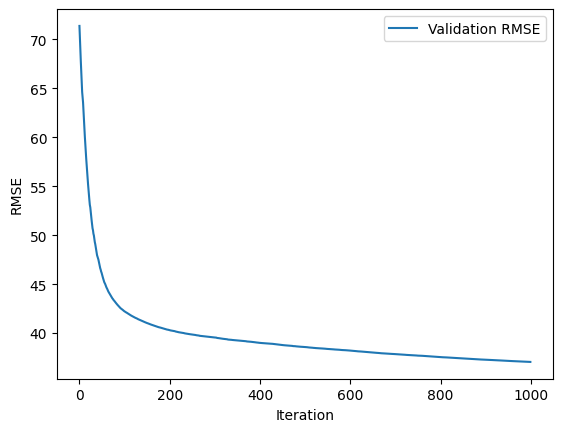


✓ Model training complete in 4.87 minutes!
🧠 Best iteration: 999
📉 Best RMSE: 37.0570

📊 Final Evaluation Results (Validation Set):
  → RMSE (last): 37.0570


In [17]:
# ============================================================
# STEP 4: Model Training (XGBoost + Early Stopping + Progress)
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: Training XGBoost Regressor with Early Stopping + Progress Bar")
print("=" * 60)

from xgboost import XGBRegressor, callback
from tqdm import tqdm
import time

start_time = time.time()
n_estimators = 1000

# --- Initialize model ---
model = XGBRegressor(
    n_estimators=n_estimators,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.85,
    colsample_bytree=0.75,
    reg_lambda=2.0,
    reg_alpha=0.2,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",   # set to 'gpu_hist' if GPU is available
    verbosity=0
)

# --- Custom tqdm callback using TrainingCallback base class ---
class TQDMCallback(callback.TrainingCallback):
    def __init__(self, total_rounds=1000, update_every=10):
        self.total_rounds = total_rounds
        self.update_every = update_every
        self.pbar = tqdm(total=total_rounds, desc="Fitting XGBoost", ncols=90)

    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        if epoch % self.update_every == 0:
            # Show current RMSE if available
            if "validation_0" in evals_log and "rmse" in evals_log["validation_0"]:
                rmse_val = evals_log["validation_0"]["rmse"][-1]
                self.pbar.set_postfix({"RMSE": f"{rmse_val:.4f}"})
        return False  # False = continue training

    def after_training(self, model):
        self.pbar.close()
        return model

print("Training model...\n")

# --- Train model with early stopping ---
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    early_stopping_rounds=50,
    verbose=False,
    callbacks=[TQDMCallback(total_rounds=n_estimators, update_every=20)]
)
eval_results = model.evals_result()
import matplotlib.pyplot as plt

plt.plot(eval_results["validation_0"]["rmse"], label="Validation RMSE")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.legend()
plt.show()
elapsed = time.time() - start_time
print(f"\n✓ Model training complete in {elapsed/60:.2f} minutes!")
# Access Booster attributes safely
best_iteration = model.get_booster().best_iteration if hasattr(model.get_booster(), "best_iteration") else model.best_ntree_limit
best_score = model.best_score if hasattr(model, "best_score") else None

print(f"🧠 Best iteration: {best_iteration}")
if best_score is not None:
    print(f"📉 Best RMSE: {float(best_score):.4f}")
else:
    print("📉 RMSE info not directly available — check eval history below.")

# Optional: Show final evaluation results
results = model.evals_result()
if "validation_0" in results:
    print("\n📊 Final Evaluation Results (Validation Set):")
    print(f"  → RMSE (last): {results['validation_0']['rmse'][-1]:.4f}")


In [20]:
# ===========================
# Step 4: AQI Category Classification
# ===========================
print("\n" + "=" * 60)
print("STEP 4: AQI Category Classification")
print("=" * 60)

def pm25_to_aqi(pm25):
    """Convert PM2.5 concentration to AQI category"""
    if pm25 <= 12:
        return "Good"
    elif pm25 <= 35.4:
        return "Moderate"
    elif pm25 <= 55.4:
        return "Unhealthy for Sensitive"
    elif pm25 <= 150.4:
        return "Unhealthy"
    elif pm25 <= 250.4:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# Apply AQI categorization
df_ae["PM2.5_Predicted"] = y_pred_all
df_ae["AQI_Category_Actual"] = df_ae["PM2.5 (ug/m3)"].apply(pm25_to_aqi)
df_ae["AQI_Category_Predicted"] = df_ae["PM2.5_Predicted"].apply(pm25_to_aqi)

# Classification report
print("\n📋 AQI Classification Report:")
print(classification_report(df_ae["AQI_Category_Actual"], df_ae["AQI_Category_Predicted"]))


# ===========================
# Step 5: Detect Unusual Air Quality (Anomalies)
# ===========================
print("\n" + "=" * 60)
print("STEP 5: Anomaly Detection")
print("=" * 60)

# Compute prediction residuals
df_ae["residual"] = np.abs(df_ae["PM2.5 (ug/m3)"] - df_ae["PM2.5_Predicted"])

# --- Handle AE reconstruction MSE gracefully ---
if "ae_recon_mse" not in df_ae.columns:
    ae_feats = [c for c in df_ae.columns if c.startswith("ae_feat_")]
    if len(ae_feats) > 0:
        print("⚠️ 'ae_recon_mse' not found — using AE feature variance as proxy.")
        df_ae["ae_recon_mse"] = df_ae[ae_feats].var(axis=1)
    else:
        print("⚠️ No AE data found — anomaly detection will use residuals only.")
        df_ae["ae_recon_mse"] = 0.0  # dummy column for consistency

# Compute thresholds
threshold_recon = df_ae["ae_recon_mse"].quantile(0.98)
threshold_resid = df_ae["residual"].quantile(0.98)

print(f"Reconstruction MSE threshold (98th percentile): {threshold_recon:.6f}")
print(f"Residual threshold (98th percentile): {threshold_resid:.4f}")

# Flag anomalies
df_ae["Unusual_AQI"] = np.where(
    (df_ae["ae_recon_mse"] > threshold_recon) | (df_ae["residual"] > threshold_resid),
    1, 0
)

# Summary
num_anomalies = df_ae["Unusual_AQI"].sum()
anomaly_pct = (num_anomalies / len(df_ae)) * 100

print(f"\n🚨 Detected {num_anomalies:,} unusual AQI readings ({anomaly_pct:.2f}%)")



STEP 4: AQI Category Classification

📋 AQI Classification Report:
                         precision    recall  f1-score   support

                   Good       0.75      0.47      0.58    193901
              Hazardous       0.79      0.55      0.65     58053
               Moderate       0.74      0.69      0.72    704445
              Unhealthy       0.68      0.81      0.74    672598
Unhealthy for Sensitive       0.48      0.51      0.50    430028
         Very Unhealthy       0.58      0.56      0.57    127546

               accuracy                           0.66   2186571
              macro avg       0.67      0.60      0.62   2186571
           weighted avg       0.67      0.66      0.66   2186571


STEP 5: Anomaly Detection
⚠️ 'ae_recon_mse' not found — using AE feature variance as proxy.
Reconstruction MSE threshold (98th percentile): nan
Residual threshold (98th percentile): 90.5004

🚨 Detected 43,732 unusual AQI readings (2.00%)



STEP 6: Generating Visualizations
✓ Visualizations saved as 'pm25_aqi_analysis.png'


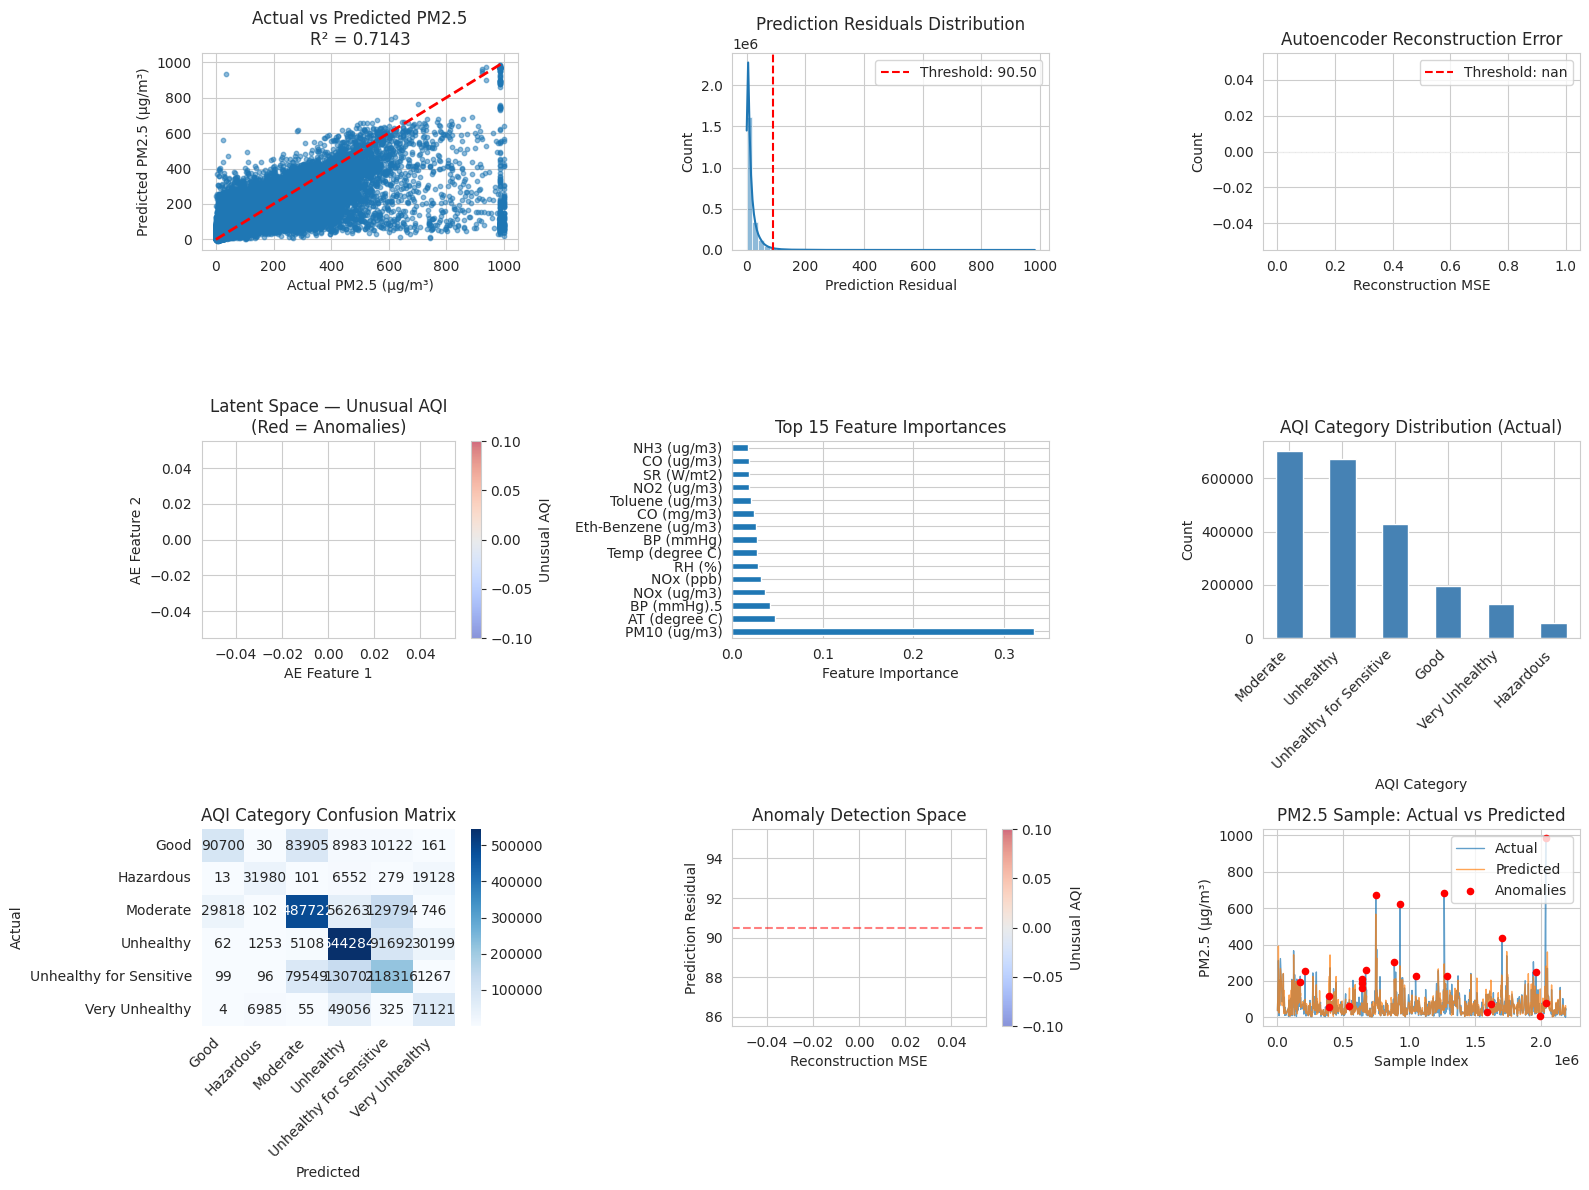

In [22]:

# ===========================
# Step 6: Visualizations
# ===========================
print("\n" + "=" * 60)
print("STEP 6: Generating Visualizations")
print("=" * 60)

# Set style
sns.set_style("whitegrid")
fig = plt.figure(figsize=(16, 12))

# 1. Actual vs Predicted PM2.5
ax1 = plt.subplot(3, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual PM2.5 (µg/m³)')
plt.ylabel('Predicted PM2.5 (µg/m³)')
plt.title(f'Actual vs Predicted PM2.5\nR² = {r2:.4f}')

# 2. Residual Distribution
ax2 = plt.subplot(3, 3, 2)
sns.histplot(df_ae["residual"], bins=50, kde=True)
plt.axvline(threshold_resid, color='r', linestyle='--', label=f'Threshold: {threshold_resid:.2f}')
plt.xlabel('Prediction Residual')
plt.ylabel('Count')
plt.title('Prediction Residuals Distribution')
plt.legend()

# 3. Reconstruction Error Distribution
ax3 = plt.subplot(3, 3, 3)
sns.histplot(df_ae["ae_recon_mse"], bins=50, kde=True)
plt.axvline(threshold_recon, color='r', linestyle='--', label=f'Threshold: {threshold_recon:.4f}')
plt.xlabel('Reconstruction MSE')
plt.ylabel('Count')
plt.title('Autoencoder Reconstruction Error')
plt.legend()

# 4. Latent Space - Anomalies
ax4 = plt.subplot(3, 3, 4)
scatter = plt.scatter(df_ae["ae_feat_1"], df_ae["ae_feat_2"],
                     c=df_ae["Unusual_AQI"], cmap="coolwarm", s=8, alpha=0.6)
plt.colorbar(scatter, label='Unusual AQI')
plt.xlabel('AE Feature 1')
plt.ylabel('AE Feature 2')
plt.title('Latent Space — Unusual AQI\n(Red = Anomalies)')

# 5. Feature Importance
ax5 = plt.subplot(3, 3, 5)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
importance = pd.Series(model.feature_importances_, index=X_scaled_df.columns)
top_features = importance.nlargest(15)
top_features.plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()

# 6. AQI Category Distribution
ax6 = plt.subplot(3, 3, 6)
aqi_counts = df_ae["AQI_Category_Actual"].value_counts()
aqi_counts.plot(kind='bar', color='steelblue')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.title('AQI Category Distribution (Actual)')
plt.xticks(rotation=45, ha='right')

# 7. Confusion Matrix (simplified)
ax7 = plt.subplot(3, 3, 7)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(df_ae["AQI_Category_Actual"], df_ae["AQI_Category_Predicted"])
categories = sorted(df_ae["AQI_Category_Actual"].unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('AQI Category Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 8. Residual vs Reconstruction Error
ax8 = plt.subplot(3, 3, 8)
plt.scatter(df_ae["ae_recon_mse"], df_ae["residual"], 
           c=df_ae["Unusual_AQI"], cmap="coolwarm", s=5, alpha=0.6)
plt.axvline(threshold_recon, color='red', linestyle='--', alpha=0.5)
plt.axhline(threshold_resid, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Reconstruction MSE')
plt.ylabel('Prediction Residual')
plt.title('Anomaly Detection Space')
plt.colorbar(label='Unusual AQI')

# 9. PM2.5 Time Series (if index is ordered)
ax9 = plt.subplot(3, 3, 9)
sample_idx = np.random.choice(len(df_ae), size=min(1000, len(df_ae)), replace=False)
sample_idx = np.sort(sample_idx)
plt.plot(sample_idx, df_ae.iloc[sample_idx]["PM2.5 (ug/m3)"], 
        label='Actual', alpha=0.7, linewidth=1)
plt.plot(sample_idx, df_ae.iloc[sample_idx]["PM2.5_Predicted"], 
        label='Predicted', alpha=0.7, linewidth=1)
anomaly_idx = sample_idx[df_ae.iloc[sample_idx]["Unusual_AQI"] == 1]
plt.scatter(anomaly_idx, df_ae.iloc[anomaly_idx]["PM2.5 (ug/m3)"], 
           color='red', s=20, label='Anomalies', zorder=5)
plt.xlabel('Sample Index')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('PM2.5 Sample: Actual vs Predicted')
plt.legend()

plt.tight_layout()
plt.savefig('pm25_aqi_analysis.png', dpi=200, bbox_inches='tight')
print("✓ Visualizations saved as 'pm25_aqi_analysis.png'")
plt.show()



STEP 7: Model Explainability (SHAP)
Computing SHAP values (this may take a moment)...
✓ SHAP summary plot saved as 'shap_summary.png'


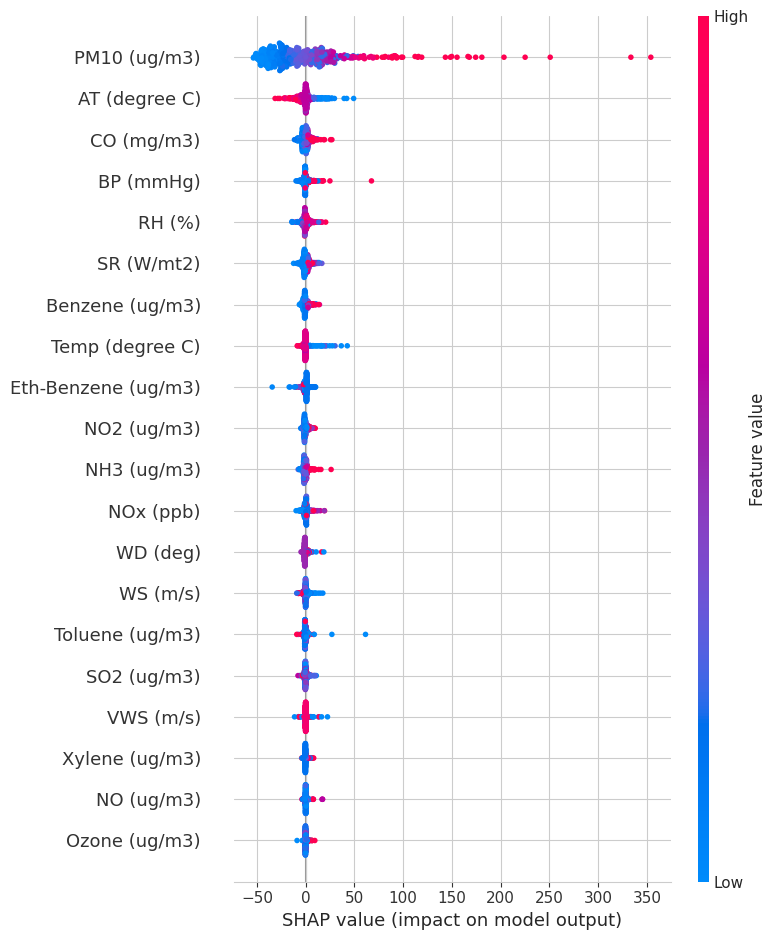

In [24]:
# ===========================
# Step 7: Model Explainability (SHAP)
# ===========================
print("\n" + "=" * 60)
print("STEP 7: Model Explainability (SHAP)")
print("=" * 60)

try:
    import shap

    # Ensure X_test has column names
    if isinstance(X_test, np.ndarray):
        X_test_df = pd.DataFrame(X_test, columns=X.columns)
    else:
        X_test_df = X_test.copy()

    # Use a subset for faster computation
    X_sample = X_test_df.sample(min(500, len(X_test_df)), random_state=42)

    print("Computing SHAP values (this may take a moment)...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_sample)

    # Summary plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=200, bbox_inches='tight')
    print("✓ SHAP summary plot saved as 'shap_summary.png'")
    plt.show()

except ImportError:
    print("⚠ SHAP not installed. Install with: pip install shap")
except Exception as e:
    print(f"⚠ Could not generate SHAP plots: {e}")


In [26]:
# ===========================
# Step 8: Summary Statistics
# ===========================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\n✅ Model trained successfully!")
print(f"   • Features used: {X_scaled.shape[1]} (original + autoencoder)")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Test samples: {len(X_test)}")

print(f"\n📊 Performance:")
print(f"   • R² Score: {r2:.4f}")
print(f"   • RMSE: {rmse:.4f} µg/m³")
print(f"   • MAE: {mae:.4f} µg/m³")

print(f"\n🚨 Anomaly Detection:")
print(f"   • Total anomalies detected: {num_anomalies} ({anomaly_pct:.2f}%)")

# Handle missing AE reconstruction metric gracefully
if 'ae_recon_mse' in df_ae.columns:
    print(f"   • Reconstruction MSE threshold: {threshold_recon:.6f}")
else:
    print(f"   • Reconstruction MSE threshold: N/A (AE recon not used)")

print(f"   • Residual threshold: {threshold_resid:.4f}")

print(f"\n📋 New columns added to df_ae:")
print(f"   • PM2.5_Predicted")
print(f"   • AQI_Category_Actual")
print(f"   • AQI_Category_Predicted")
print(f"   • residual")
print(f"   • Unusual_AQI")

# Show sample of unusual readings (with safe handling for missing ae_recon_mse)
if num_anomalies > 0:
    print(f"\n🔍 Sample of unusual AQI readings:")
    cols_to_show = [
        "PM2.5 (ug/m3)",
        "PM2.5_Predicted",
        "residual",
        "AQI_Category_Actual"
    ]
    if 'ae_recon_mse' in df_ae.columns:
        cols_to_show.insert(3, "ae_recon_mse")  # Add it only if it exists

    anomaly_sample = df_ae[df_ae["Unusual_AQI"] == 1][cols_to_show].head(5)
    print(anomaly_sample.to_string(index=False))
else:
    print("\nNo anomalies detected in this dataset.")

print("\n" + "=" * 60)
print("✓ PIPELINE COMPLETE")
print("=" * 60)



FINAL SUMMARY

✅ Model trained successfully!
   • Features used: 54 (original + autoencoder)
   • Training samples: 1749256
   • Test samples: 437315

📊 Performance:
   • R² Score: 0.7143
   • RMSE: 38.8424 µg/m³
   • MAE: 18.0208 µg/m³

🚨 Anomaly Detection:
   • Total anomalies detected: 43732 (2.00%)
   • Reconstruction MSE threshold: nan
   • Residual threshold: 90.5004

📋 New columns added to df_ae:
   • PM2.5_Predicted
   • AQI_Category_Actual
   • AQI_Category_Predicted
   • residual
   • Unusual_AQI

🔍 Sample of unusual AQI readings:
 PM2.5 (ug/m3)  PM2.5_Predicted   residual  ae_recon_mse AQI_Category_Actual
         151.5       242.860229  91.360229           NaN      Very Unhealthy
          68.0       166.342834  98.342834           NaN           Unhealthy
          99.0       191.835190  92.835190           NaN           Unhealthy
         169.0       289.896790 120.896790           NaN      Very Unhealthy
         288.0       393.891296 105.891296           NaN           